In [18]:
import pandas as pd

data = {
    'Hours_Studied': [2, 5, 3, 8, 6, None, 4, 7, 1, 9],
    'Attendance': [80, 90, None, 95, 85, 88, 92, None, 70, 98],
    'Previous_Score': [50, 60, 55, 80, 75, 65, None, 85, 40, 90],
    'Gender': ['Male', 'Female', 'Female', 'Male', None, 'Male', 'Female', 'Female', 'Male', 'Male'],
    'Final_Score': [55, 65, 60, 85, 78, 70, 68, 88, 50, 92]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Attendance,Previous_Score,Gender,Final_Score
0,2.0,80.0,50.0,Male,55
1,5.0,90.0,60.0,Female,65
2,3.0,NaN,55.0,Female,60
3,8.0,95.0,80.0,Male,85
4,6.0,85.0,75.0,NaN,78
5,NaN,88.0,65.0,Male,70
6,4.0,92.0,NaN,Female,68
7,7.0,NaN,85.0,Female,88
8,1.0,70.0,40.0,Male,50
9,9.0,98.0,90.0,Male,92


In [19]:
df.isnull().sum()

Hours_Studied     1
Attendance        2
Previous_Score    1
Gender            1
Final_Score       0
dtype: int64

In [20]:
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean(),inplace =True) 
df['Hours_Studied']= df['Hours_Studied'].fillna(df['Hours_Studied'].mean(),inplace = True) 
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0],inplace = True) 
df['Previous_Score']=df['Previous_Score'].fillna(df['Previous_Score'].mean(),inplace = True)



C:\Users\solan\AppData\Local\Temp\ipykernel_26688\1149898605.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean(),inplace =True)
C:\Users\solan\AppData\Local\Temp\ipykernel_26688\1149898605.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

In [21]:
df.drop_duplicates(inplace= True)

In [22]:
df

,Hours_Studied,Attendance,Previous_Score,Gender,Final_Score
0,2.0,80.00,50.000000,Male,55
1,5.0,90.00,60.000000,Female,65
2,3.0,87.25,55.000000,Female,60
3,8.0,95.00,80.000000,Male,85
4,6.0,85.00,75.000000,Male,78
5,5.0,88.00,65.000000,Male,70
6,4.0,92.00,66.666667,Female,68
7,7.0,87.25,85.000000,Female,88
8,1.0,70.00,40.000000,Male,50
9,9.0,98.00,90.000000,Male,92


In [23]:

!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\solan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
df["Gender "] = le.fit_transform(df['Gender']) 
df

,Hours_Studied,Attendance,Previous_Score,Gender,Final_Score,Gender
0,2.0,80.00,50.000000,Male,55,1
1,5.0,90.00,60.000000,Female,65,0
2,3.0,87.25,55.000000,Female,60,0
3,8.0,95.00,80.000000,Male,85,1
4,6.0,85.00,75.000000,Male,78,1
5,5.0,88.00,65.000000,Male,70,1
6,4.0,92.00,66.666667,Female,68,0
7,7.0,87.25,85.000000,Female,88,0
8,1.0,70.00,40.000000,Male,50,1
9,9.0,98.00,90.000000,Male,92,1


In [25]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
df[['Hours_Studied','Attendance','Previous_Score']] = scaler.fit_transform( 
    df[['Hours_Studied','Attendance','Previous_Score']]
) 
df

,Hours_Studied,Attendance,Previous_Score,Gender,Final_Score,Gender
0,-1.224745,-0.967527,-1.098967,Male,55,1
1,0.000000,0.366993,-0.439587,Female,65,0
2,-0.816497,0.000000,-0.769277,Female,60,0
3,1.224745,1.034253,0.879174,Male,85,1
4,0.408248,-0.300267,0.549484,Male,78,1
5,0.000000,0.100089,-0.109897,Male,70,1
6,-0.408248,0.633897,0.000000,Female,68,0
7,0.816497,0.000000,1.208864,Female,88,0
8,-1.632993,-2.302047,-1.758348,Male,50,1
9,1.632993,1.434609,1.538554,Male,92,1


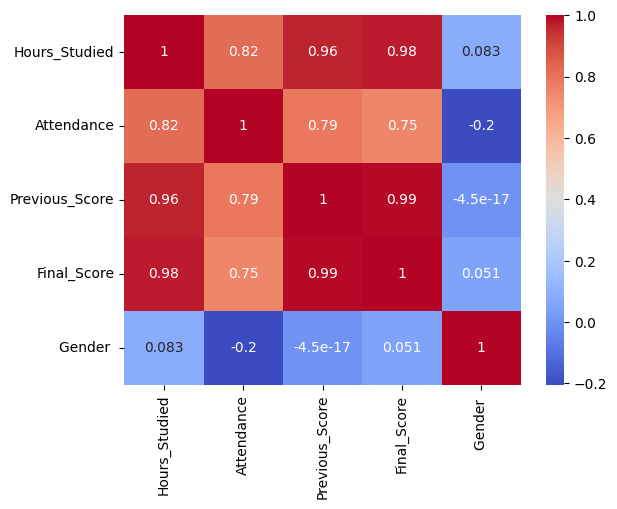

In [26]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.heatmap(df.corr(numeric_only = True), annot =True, cmap = 'coolwarm') 
plt.show()

<Axes: >

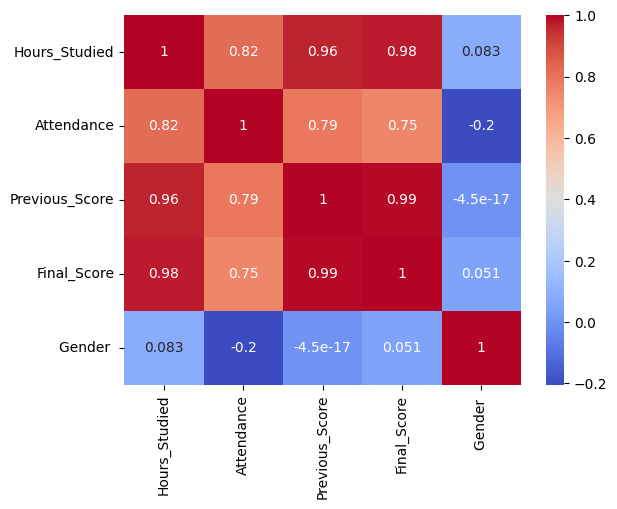

In [27]:
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = "coolwarm")